# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel. Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


## 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [350]:
# BIBLIOTECAS UTILIZADAS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [351]:
# IMPORTAÇÃO DE BIBLIOTECAS

df = pd.read_csv('ALUGUEL.csv', sep=';')
df.columns = df.columns.str.upper()

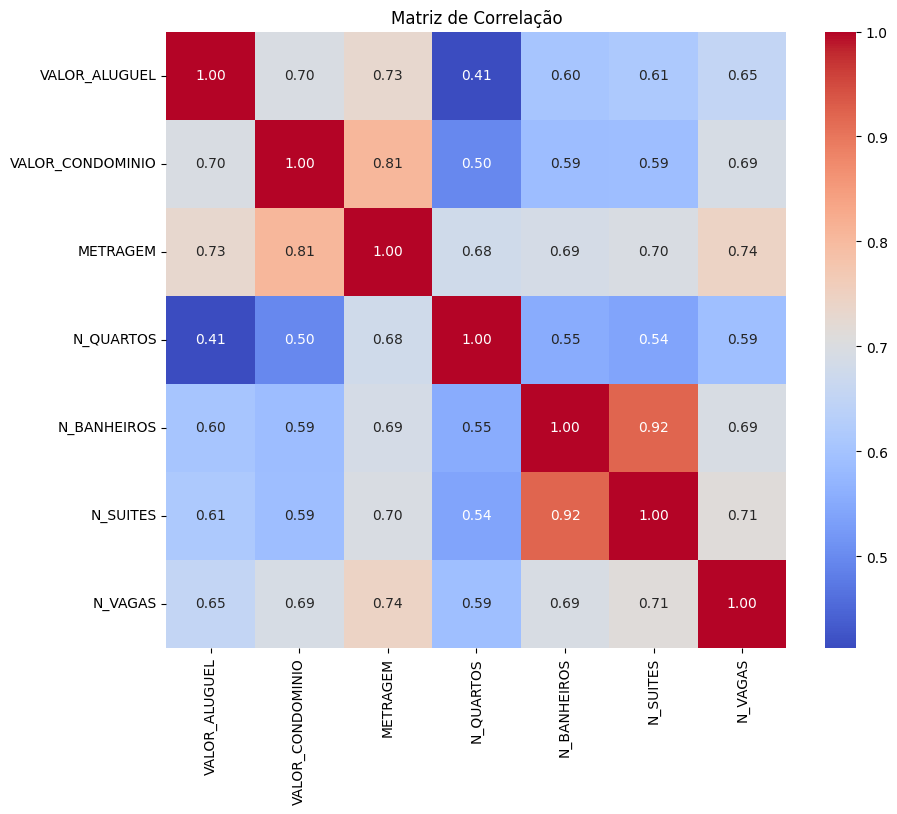

In [352]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Utilizaremos a variável `METRAGEM` por ter uma forte correlação com a nossa variável target `VALOR_ALUGUEL`.

In [353]:
# SEPARAÇÃO DE VARIÁVEIS UTILIZADAS NA REGRESSÃO POLINOMIAL

x = df[['VALOR_ALUGUEL']]
y = df[['METRAGEM']]

## 2 - Faça o processamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [354]:
# REGRESSÃO POLINOMIAL DE GRAU 2

poly_features = PolynomialFeatures(degree=2)

## 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [355]:
# SEPARAÇÃO DE BASE DE TREINO E TESTE

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0
)

In [356]:
# TREINAMENTO E APLICAÇÃO DO MODELO NA BASE DE TREINO

x_train_poly = poly_features.fit_transform(x_train)

model = LinearRegression()
model.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

In [357]:
# APLICAÇÃO DO MODELO NA BASE 

x_test_poly = poly_features.transform(x_test)
y_pred = model.predict(x_test_poly)

x_range = np.linspace(
    x.values.min(),
    x.values.max(),
    100
)

x_range = pd.DataFrame(x_range, columns=x_train.columns)

x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

In [358]:
# METRICAS DE AVALIAÇÃO DO MODELO

mse_grau_2 = mean_squared_error(y_test, y_pred)
mae_grau_2 = mean_absolute_error(y_test, y_pred)
r2_grau_2 = r2_score(y_test, y_pred)

print("AVALIAÇÃO DE MÉTRICAS DO MODELO\n")
print("MAE: ", round(mae_grau_2, 3))
print("MSE: ", round(mse_grau_2, 3))
print("R²: ", round(r2_grau_2, 3))

AVALIAÇÃO DE MÉTRICAS DO MODELO

MAE:  25.312
MSE:  1728.368
R²:  0.553


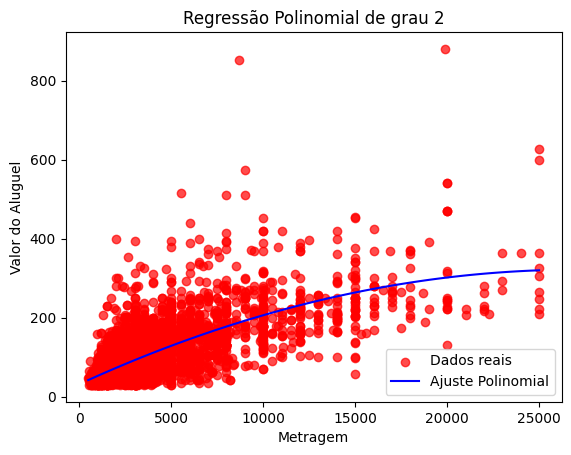

In [359]:
# GRÁFICO DE DISPERSÃO COM O AJUSTE POLINOMIAL DE GRAU 2

plt.scatter(x, y, color='red', label='Dados reais', alpha=0.7)
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial') 
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial de grau 2')
plt.legend()
plt.show()

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4.

In [360]:
# REGRESSÃO POLINOMIAL DE GRAU 4

poly_features = PolynomialFeatures(degree=4)

x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)

model = LinearRegression()
model.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [361]:
# APLICAÇÃO DO MODELO NA BASE DE TESTE

x_test_poly = poly_features.transform(x_test)
y_pred = model.predict(x_test_poly)

x_range = np.linspace(
    x.values.min(),
    x.values.max(),
    100
)

x_range = pd.DataFrame(x_range, columns=x_train.columns)

x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

In [362]:
# METRICAS DE AVALIAÇÃO DO MODELO DE GRAU 4

mse_grau_4 = mean_squared_error(y_test, y_pred)
mae_grau_4 = mean_absolute_error(y_test, y_pred)
r2_grau_4 = r2_score(y_test, y_pred)

print("AVALIAÇÃO DE MÉTRICAS DO MODELO\n")
print("MAE: ", round(mae_grau_4, 3))
print("MSE: ", round(mse_grau_4, 3))
print("R²: ", round(r2_grau_4, 3))

AVALIAÇÃO DE MÉTRICAS DO MODELO

MAE:  25.698
MSE:  1781.703
R²:  0.539


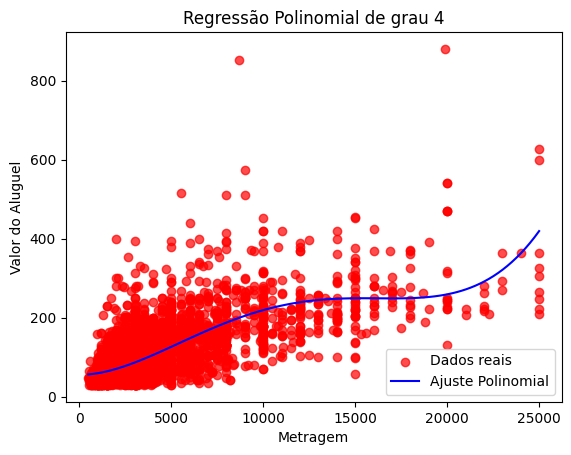

In [363]:
# GRÁFICO DE DISPERSÃO COM O AJUSTE POLINOMIAL DE GRAU 4

plt.scatter(x, y, color='red', label='Dados reais', alpha=0.7)
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial') 
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial de grau 4')
plt.legend()
plt.show()

## Avalie se o resultado desse novo modelo está superior ao anterior.

In [364]:
diff_mae = mae_grau_2 - mae_grau_4
diff_mse = mse_grau_2 - mse_grau_4
diff_r2 = r2_grau_2 - r2_grau_4

print("COMPARAÇÃO ENTRE AS MÉTRICAS DOS MODELOS DE GRAU 2 E GRAU 4\n")
print("MODELO DE GRAU 2 - MODELO DE GRAU 4")
print("MAE: ", round(diff_mae, 3))
print("MSE: ", round(diff_mse, 3))
print("R²: ", round(diff_r2, 3))

COMPARAÇÃO ENTRE AS MÉTRICAS DOS MODELOS DE GRAU 2 E GRAU 4

MODELO DE GRAU 2 - MODELO DE GRAU 4
MAE:  -0.386
MSE:  -53.336
R²:  0.014


**ANÁLISE:** Podemos observar que em relação à métrica de MAE (que calcula as diferenças absolutas entre valores previstos e reais) e de MSE (média dos quadrados da diferença entre valores previstos e reais), o modelo de grau 2, obteve resultados menores, o que indica um melhor desempenho. Além disso, apesar de modelo de grau quadrático ter o $R^2$ maior que o modelo de grau 4, a diferença é muito pequena. Ou seja, o modelo de grau 2 se comporta melhor

Apesar disso, vale destacar que a diferença é pequena para todas as métricas. Isso pode ser explicado pelo fato de que na faixa inicial (metragem de 0- 15000) os dados estão mais adensados e o comportamento da curva é semelhante, a diferença maior está na faixa que possui uma metragem entre 20000-25000, ou seja, na menor parte do gráfico.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
Minimo: 4 linhas.

Primeiramente, é importante destacar os pontos que são em comum entre eos objetos estudados. Ambos são tipos de regressão para melhoria de performance utilizadas principalmente para a prevenção de overfitting.

A **regressão Lasso** tem objetivo de simplificar o modelo, reduzindo coeficientes, com base na penalização L1 (penalização é calculada na soma dos valores absolutos dos coeficientes) junto ao parâmetro de regularização $\lambda_1$. 

A **regressão Ridge** segue os mesmos principios, mas de maneira diferente: ela utiliza como base a penalização L2 (que é calculada pela soma dos quadrados dos coeficientes) junto ao parâmetro de regularização $\lambda_2$. ,como consequência penaliza coeficientes muito grandes. Sua principal vantagem é a estabilização do modelo.

Por fim, a **Elastic Net** é uma combinação das duas anteriores procurando trazer simplificação e estabilidade usando ambas penalidades L1 e L2. 